In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
from scipy import stats 
from sklearn.compose import ColumnTransformer 
from sklearn.model_selection import train_test_split,  StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, f1_score
import pickle

In [2]:
df= pd.read_csv('disease_prediction.csv')
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [3]:
df.shape

(1000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [5]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [6]:
df= df.drop('patient_id', axis=1)

In [7]:
df.isna().sum()

age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

In [8]:
df.nunique()

age                     68
gender                   2
glucose_mg_dl          131
cholesterol_mg_dl      188
systolic_bp             94
diastolic_bp            56
bmi                    206
heart_rate              58
smoking                  2
alcohol_consumption      2
physical_activity        3
family_history           2
disease                  2
dtype: int64

In [9]:
df.duplicated(keep=False).sum()

np.int64(0)

1. The dataset has 14 columns with 1000 entries, each entry represents a patient. 
2. The dataset has a single float column, 7 integer columns, and 6 object columns.
3. There are no missing values.
4. There are no duplicates in the dataset
5. The columns: smoking, alcohol_consumption, family_history, gender and diseases has 2 unique values,  physical_activity also have 3 uniques values and the rest of the columns have multiple values 

In [10]:
df.columns

Index(['age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
       'diastolic_bp', 'bmi', 'heart_rate', 'smoking', 'alcohol_consumption',
       'physical_activity', 'family_history', 'disease'],
      dtype='object')

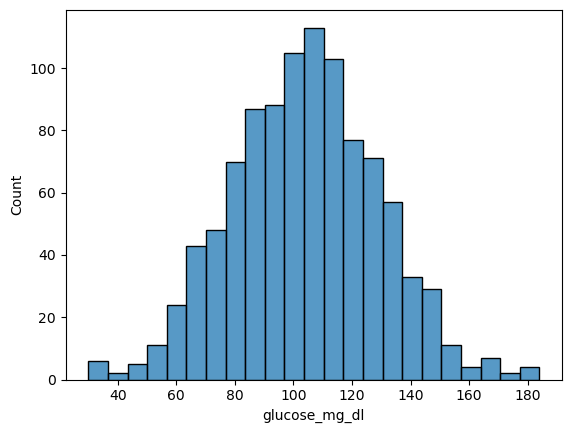

In [11]:
sns.histplot(data=df, x='glucose_mg_dl')
plt.show()

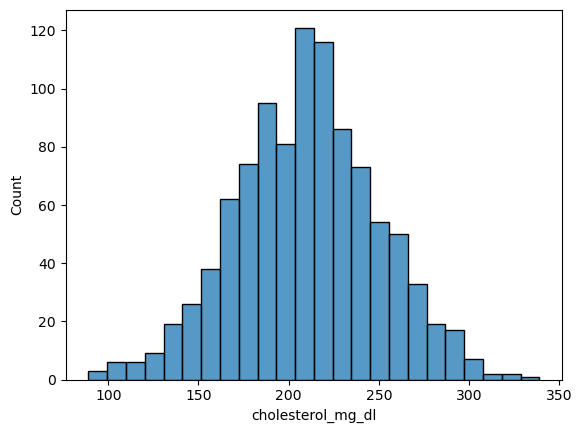

In [12]:
sns.histplot(data=df, x='cholesterol_mg_dl')
plt.show()

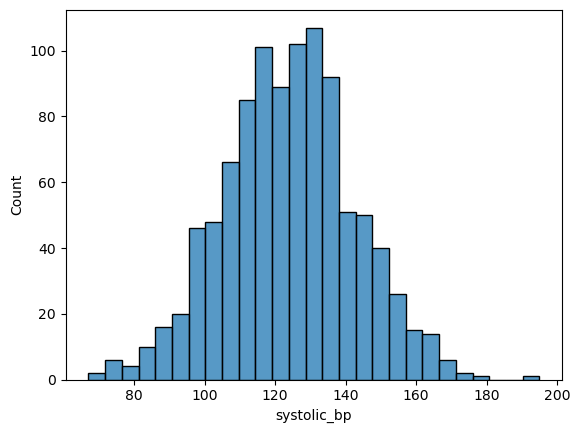

In [13]:
sns.histplot(data=df, x='systolic_bp')
plt.show()

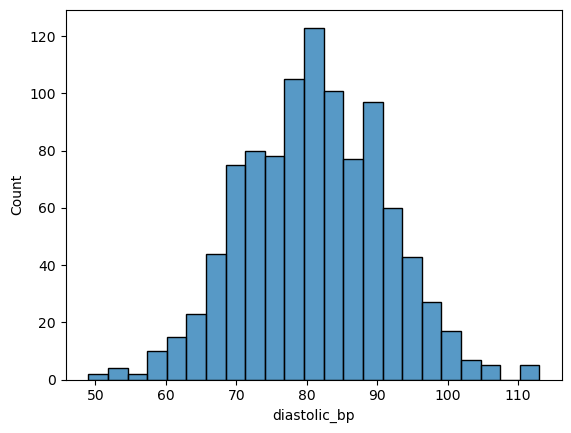

In [14]:
sns.histplot(data=df, x='diastolic_bp')
plt.show()

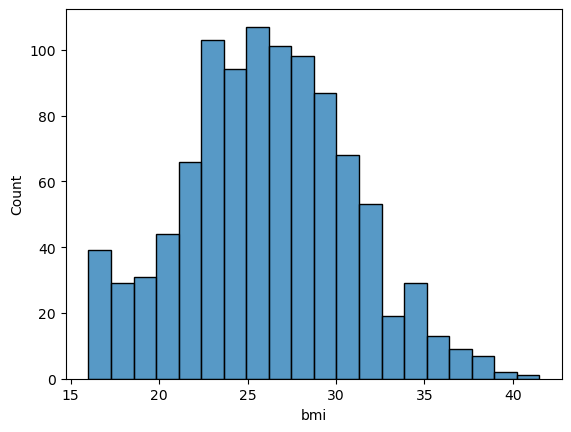

In [15]:
sns.histplot(data=df, x='bmi')
plt.show()

In [16]:
df.columns

Index(['age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
       'diastolic_bp', 'bmi', 'heart_rate', 'smoking', 'alcohol_consumption',
       'physical_activity', 'family_history', 'disease'],
      dtype='object')

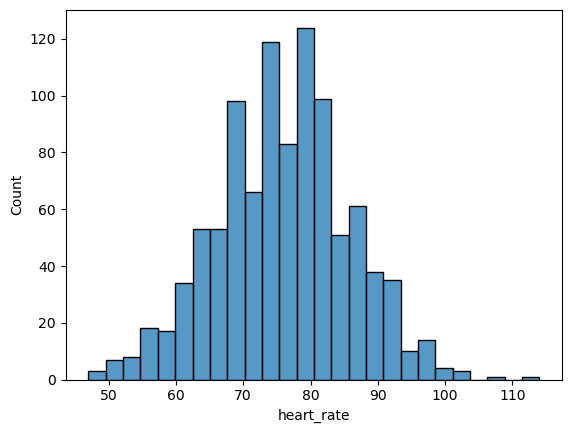

In [17]:
sns.histplot(data=df, x='heart_rate')
plt.show()

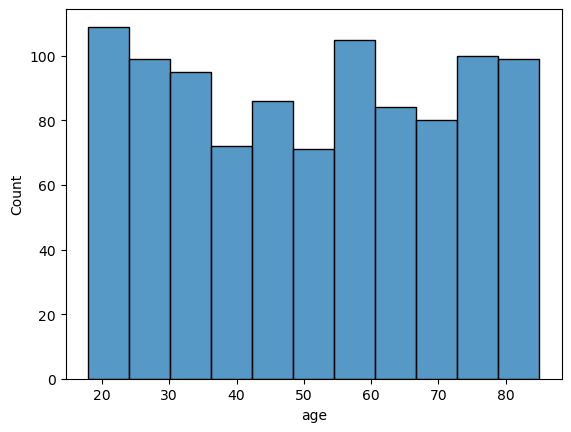

In [18]:
sns.histplot(data=df, x='age')
plt.show()

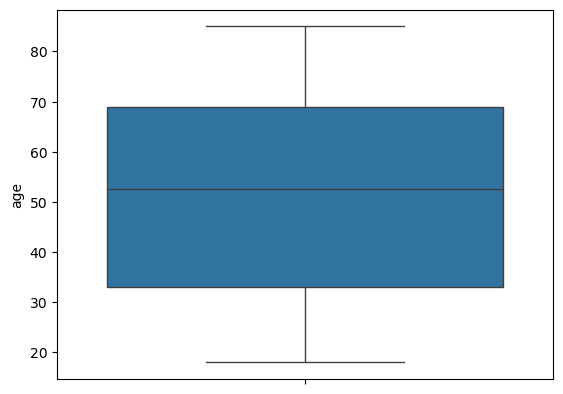

In [19]:
sns.boxplot(data=df, y='age')
plt.show()

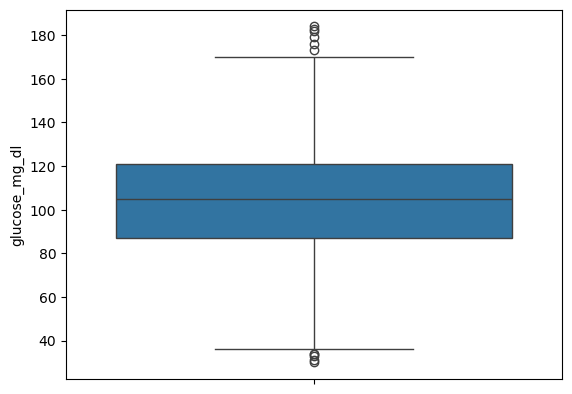

In [20]:
sns.boxplot(data=df, y='glucose_mg_dl')
plt.show()

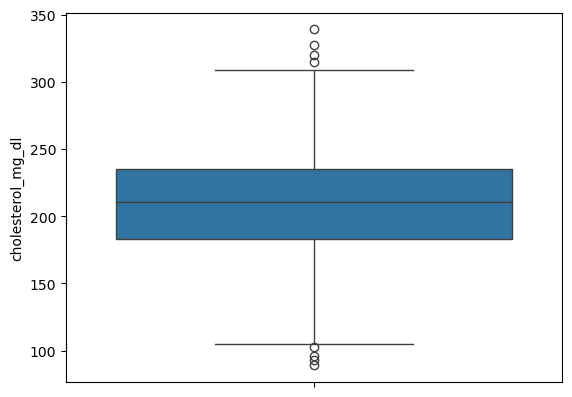

In [21]:
sns.boxplot(data=df, y='cholesterol_mg_dl')
plt.show()

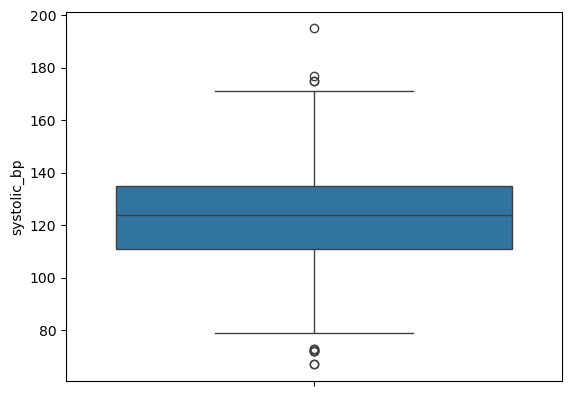

In [22]:
sns.boxplot(data=df, y='systolic_bp')
plt.show()

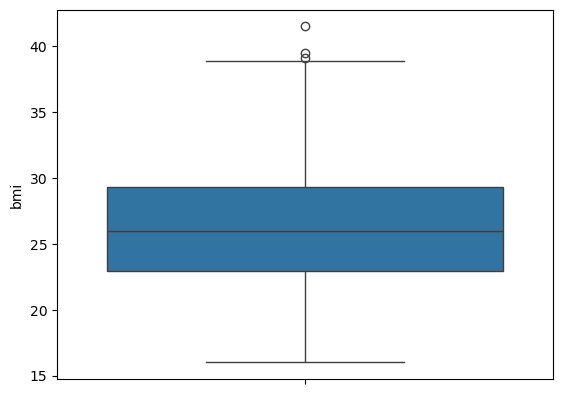

In [23]:
sns.boxplot(data=df, y='bmi')
plt.show()

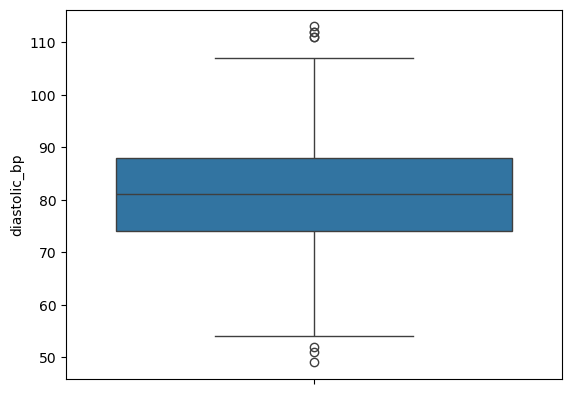

In [24]:
sns.boxplot(data=df, y='diastolic_bp')
plt.show()

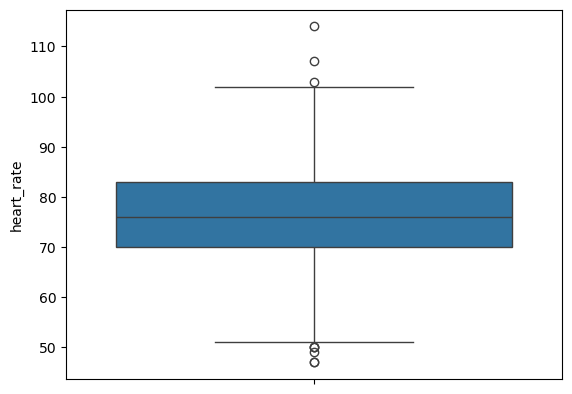

In [25]:
sns.boxplot(data=df, y='heart_rate')
plt.show()

In [26]:
df.select_dtypes('object').columns

Index(['gender', 'smoking', 'alcohol_consumption', 'physical_activity',
       'family_history', 'disease'],
      dtype='object')

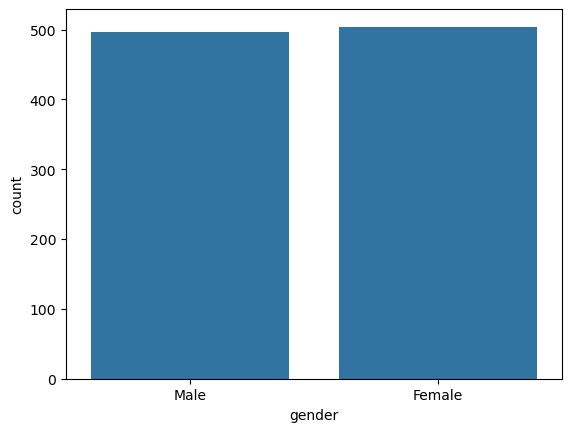

In [27]:
sns.countplot(data=df, x= 'gender')
plt.show()

In [28]:
df['gender'].value_counts(normalize=True)*100

gender
Female    50.4
Male      49.6
Name: proportion, dtype: float64

In [29]:
df['smoking'].value_counts(normalize=True)*100

smoking
Yes    50.3
No     49.7
Name: proportion, dtype: float64

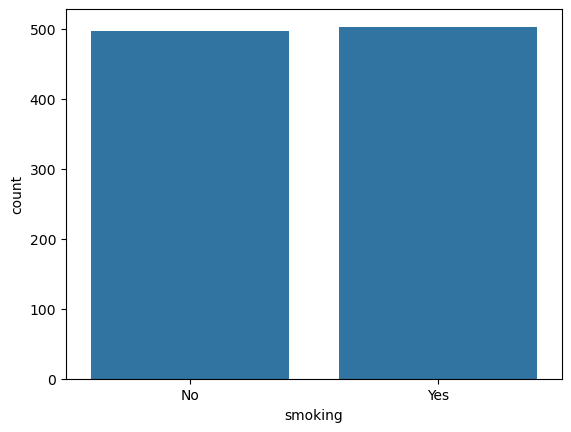

In [30]:
sns.countplot(data=df, x='smoking')
plt.show()

In [31]:
df['alcohol_consumption'].value_counts(normalize=True)*100

alcohol_consumption
Yes    50.1
No     49.9
Name: proportion, dtype: float64

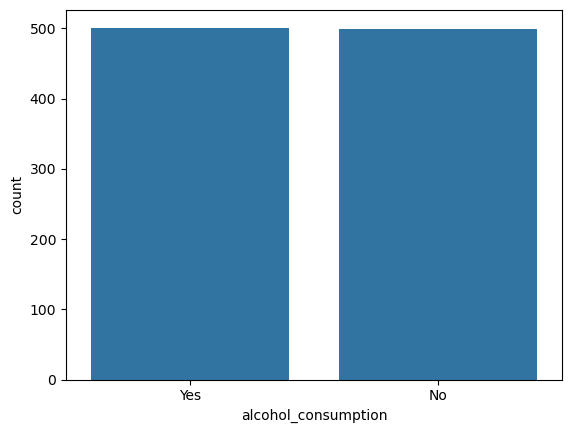

In [32]:
sns.countplot(data=df, x='alcohol_consumption')
plt.show()

In [33]:
df['physical_activity'].value_counts(normalize=True)*100

physical_activity
Medium    34.4
High      34.4
Low       31.2
Name: proportion, dtype: float64

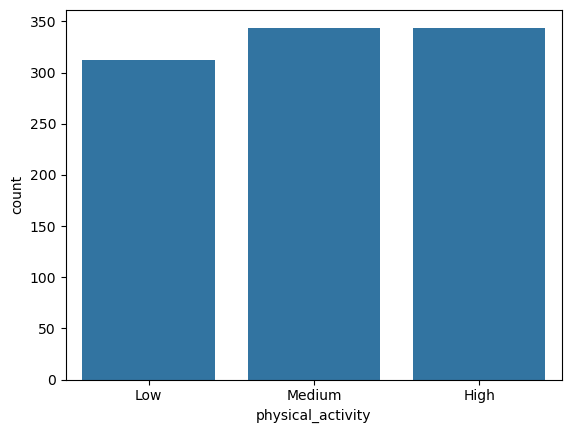

In [34]:
sns.countplot(data=df, x='physical_activity')
plt.show()

In [35]:
df['family_history'].value_counts(normalize=True)*100

family_history
No     50.4
Yes    49.6
Name: proportion, dtype: float64

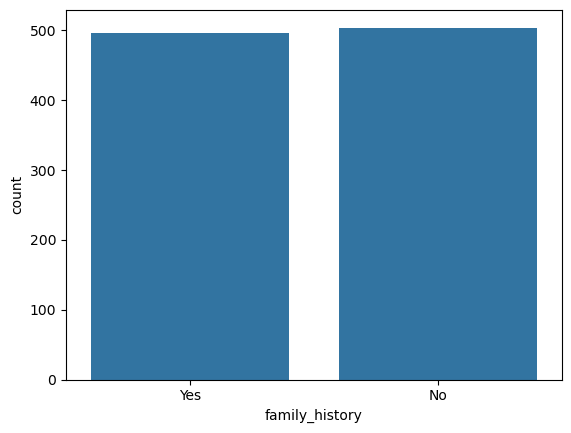

In [36]:
sns.countplot(df, x='family_history')
plt.show()

In [37]:
df['disease'].value_counts(normalize=True)*100

disease
Yes    50.1
No     49.9
Name: proportion, dtype: float64

<Axes: xlabel='disease', ylabel='count'>

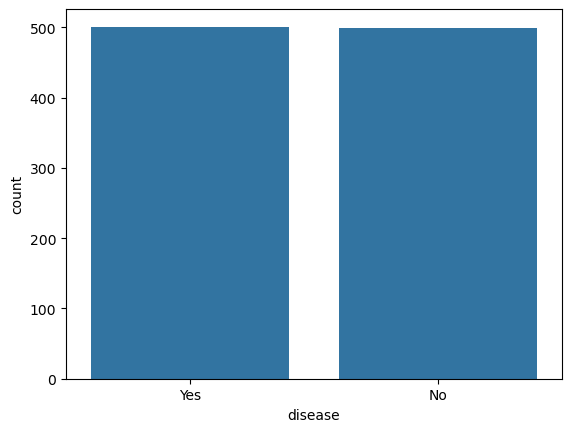

In [38]:
sns.countplot(df, x= 'disease')

In [39]:
df['disease'].value_counts(normalize=True)*100

disease
Yes    50.1
No     49.9
Name: proportion, dtype: float64

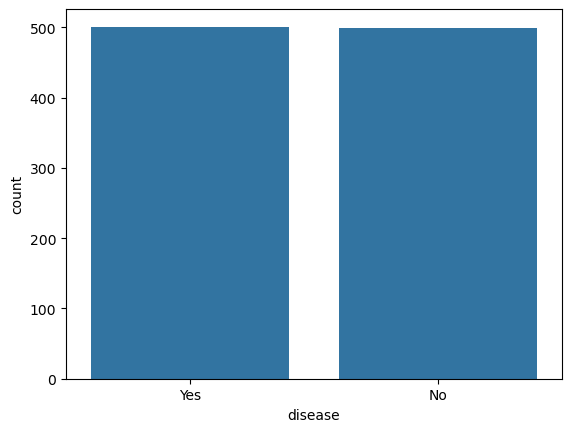

In [40]:
sns.countplot(df, x='disease')
plt.show()

In [41]:
df.select_dtypes('number').skew()

age                 -0.001806
glucose_mg_dl        0.059475
cholesterol_mg_dl   -0.026940
systolic_bp         -0.001043
diastolic_bp         0.017668
bmi                  0.093360
heart_rate          -0.014951
dtype: float64

In [42]:
q1= df['glucose_mg_dl'].quantile(0.25)
q3= df['glucose_mg_dl'].quantile(0.75)
IQR= q3 - q1
lb= q1 - 1.5*IQR
ub= q3 + 1.5*IQR

df.loc[(df['glucose_mg_dl'] < lb) | (df['glucose_mg_dl'] > ub)]

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
265,73,Female,31,227,141,58,20.6,65,Yes,Yes,Medium,No,Yes
269,27,Male,184,221,111,77,25.1,87,No,No,High,No,No
326,82,Female,183,252,129,81,16.0,78,No,Yes,Medium,Yes,Yes
339,74,Male,173,225,115,81,31.3,58,Yes,No,High,Yes,Yes
384,22,Male,182,234,121,87,36.0,84,No,Yes,High,Yes,Yes
420,49,Male,179,224,119,91,26.9,80,Yes,No,Medium,No,No
491,25,Male,30,202,95,94,26.4,83,No,Yes,Low,Yes,No
540,24,Female,176,143,144,80,26.1,83,Yes,No,Medium,Yes,Yes
672,70,Male,34,177,142,87,20.2,73,Yes,Yes,High,Yes,Yes
701,45,Female,33,175,104,79,28.5,70,No,No,Low,Yes,No


In [43]:
q1= df['cholesterol_mg_dl'].quantile(0.25)
q3= df['cholesterol_mg_dl'].quantile(0.75)
IQR= q3 - q1
lb= q1 - 1.5*IQR
ub= q3 + 1.5*IQR

df.loc[(df['cholesterol_mg_dl'] < lb) | (df['cholesterol_mg_dl'] > ub)]

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
111,79,Female,142,103,144,94,24.7,55,No,Yes,Medium,Yes,Yes
322,59,Female,102,315,97,84,23.7,80,Yes,Yes,High,Yes,Yes
337,28,Female,72,89,128,100,32.8,88,No,Yes,Low,Yes,Yes
525,63,Male,95,93,118,71,30.2,59,Yes,No,High,No,No
619,85,Male,101,339,166,80,31.1,74,No,Yes,High,No,Yes
797,48,Female,80,320,119,89,17.5,69,Yes,No,High,Yes,No
940,57,Male,91,96,149,89,29.9,58,No,Yes,Medium,No,No
974,55,Male,91,327,107,72,29.6,70,Yes,Yes,High,No,Yes


In [44]:
q1= df['systolic_bp'].quantile(0.25)
q3= df['systolic_bp'].quantile(0.75)
IQR= q3 - q1
lb= q1 - 1.5*IQR
ub= q3 + 1.5*IQR

df.loc[(df['systolic_bp'] < lb) | (df['systolic_bp'] > ub)]

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
183,63,Male,113,249,72,102,30.6,74,No,Yes,Medium,Yes,Yes
256,55,Male,91,163,73,81,28.6,93,Yes,Yes,Medium,Yes,Yes
328,61,Female,133,233,72,88,25.0,77,Yes,Yes,Medium,No,Yes
482,71,Male,110,230,195,61,29.8,93,No,Yes,High,No,No
674,77,Male,94,238,175,80,30.7,79,No,Yes,Low,No,Yes
769,73,Female,97,255,73,81,26.3,74,Yes,Yes,Low,No,Yes
772,48,Female,125,182,72,87,27.9,63,No,No,Low,No,No
787,33,Female,97,206,67,84,26.1,71,Yes,Yes,High,Yes,No
796,82,Female,135,166,67,84,25.9,78,Yes,Yes,High,No,Yes
859,58,Female,104,215,177,80,21.7,64,Yes,Yes,Medium,No,Yes


In [45]:
q1= df['diastolic_bp'].quantile(0.25)
q3= df['diastolic_bp'].quantile(0.75)
IQR= q3 - q1
lb= q1 - 1.5*IQR
ub= q3 + 1.5*IQR

df.loc[(df['diastolic_bp'] < lb) | (df['diastolic_bp'] > ub)]

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
43,23,Male,124,172,123,49,28.2,65,No,No,Low,No,No
79,51,Male,98,233,130,112,34.2,87,No,No,Medium,Yes,Yes
417,84,Female,89,166,110,111,24.3,88,No,No,Medium,Yes,No
575,26,Female,73,204,114,52,23.6,96,No,No,Medium,No,No
663,60,Male,78,264,154,113,28.8,64,Yes,Yes,Low,Yes,Yes
699,38,Male,92,253,96,51,16.0,81,Yes,Yes,Low,Yes,Yes
811,48,Male,104,215,115,112,27.0,89,No,No,Medium,No,No
870,36,Male,105,201,108,111,34.9,65,Yes,No,Medium,No,No


In [46]:
q1= df['bmi'].quantile(0.25)
q3= df['bmi'].quantile(0.75)
IQR= q3 - q1
lb= q1 - 1.5*IQR
ub= q3 + 1.5*IQR

df.loc[(df['bmi'] < lb) | (df['bmi'] > ub)]

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
429,67,Female,77,268,142,84,39.1,93,Yes,No,Low,No,Yes
966,80,Male,98,230,113,84,41.5,73,Yes,No,High,Yes,Yes
968,27,Female,99,254,150,84,39.5,67,No,Yes,Low,No,Yes


In [47]:
q1= df['heart_rate'].quantile(0.25)
q3= df['heart_rate'].quantile(0.75)
IQR= q3 - q1
lb= q1 - 1.5*IQR
ub= q3 + 1.5*IQR

df.loc[(df['heart_rate'] < lb) | (df['heart_rate'] > ub)]

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
29,83,Male,125,210,151,79,27.4,103,No,No,High,Yes,No
34,75,Male,81,230,134,87,19.1,114,No,Yes,Medium,No,No
176,65,Male,134,231,118,89,25.9,47,No,No,Medium,Yes,Yes
225,31,Female,59,231,138,76,20.1,50,Yes,Yes,Low,Yes,Yes
502,69,Female,70,186,143,66,19.6,47,Yes,Yes,Low,No,Yes
690,76,Male,145,225,130,66,29.1,49,Yes,No,High,Yes,Yes
832,36,Female,119,183,124,89,25.4,107,Yes,No,Medium,Yes,No
917,31,Female,70,190,140,71,26.8,50,Yes,No,Medium,No,No
935,72,Female,149,251,126,76,29.3,50,No,No,Low,Yes,Yes


1. All the numeric columns showed a Gaussian distribution except for age, personal_id, and bmi(almost normal distribution, 0.093360)
2. The columns: glucose_mg_dl, cholesterol_mg_dl, systolic_bp, diastolic_bp, bmi, heart_rate have few outliers but analysing the data, those outlies seem to be reasonable data point and not mistake.
3. All the object columns showed almost equal counts of each unique variable.
4. There are 1 floating column, 7 integer column and 6 object columns.

In [48]:
df.select_dtypes('number').columns

Index(['age', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
       'diastolic_bp', 'bmi', 'heart_rate'],
      dtype='object')

In [49]:
disease_age= df.groupby('disease')['age'].mean()
disease_age

disease
No     46.310621
Yes    56.049900
Name: age, dtype: float64

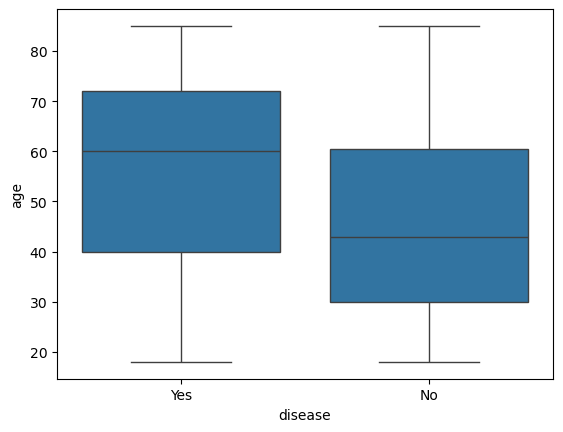

In [50]:
sns.boxplot(data= df, x='disease', y= 'age')
plt.show()

In [51]:
disease_glucose= df.groupby('disease')['glucose_mg_dl'].mean()
disease_glucose

disease
No      98.446894
Yes    109.856287
Name: glucose_mg_dl, dtype: float64

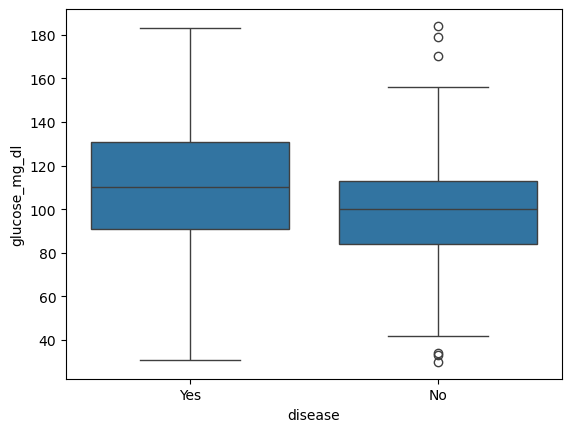

In [52]:
sns.boxplot(data= df, x='disease', y= 'glucose_mg_dl')
plt.show()

In [53]:
disease_cho= df.groupby('disease')['cholesterol_mg_dl'].mean()
disease_cho

disease
No     204.559118
Yes    215.447106
Name: cholesterol_mg_dl, dtype: float64

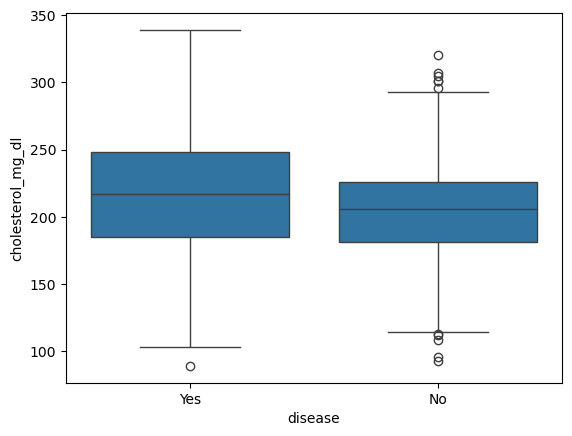

In [54]:
sns.boxplot(data=df, x= 'disease', y= 'cholesterol_mg_dl')
plt.show()

In [55]:
disease_sys= df.groupby('disease')['systolic_bp'].mean()
disease_sys

disease
No     120.308617
Yes    127.463074
Name: systolic_bp, dtype: float64

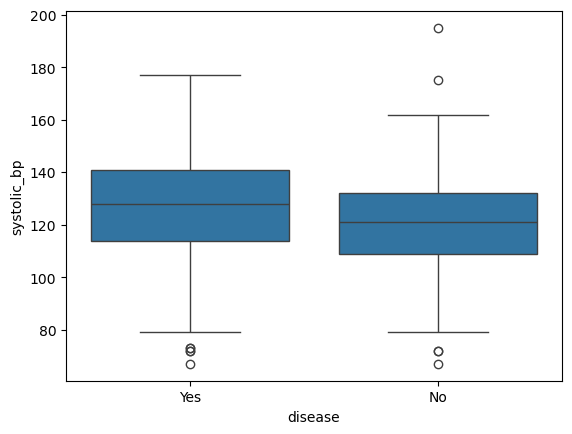

In [56]:
sns.boxplot(data= df, x='disease', y='systolic_bp')
plt.show()

In [57]:
disease_dia= df.groupby('disease')['diastolic_bp'].mean()
disease_dia

disease
No     80.987976
Yes    81.075848
Name: diastolic_bp, dtype: float64

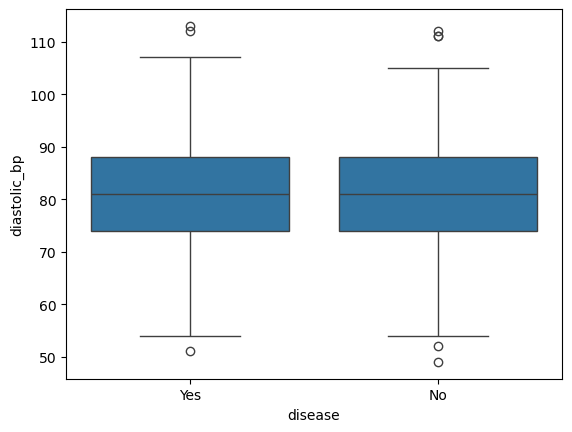

In [58]:
sns.boxplot(data=df, x='disease', y='diastolic_bp')
plt.show()

In [59]:
g= df['disease'].unique()
groups= [df.groupby('disease')['diastolic_bp'].get_group(gi)  for gi in g]
f,p = stats.f_oneway(*groups)
print(f'f-value is {f}')
print(f'p-value is {p}')

f-value is 0.0194011840280232
p-value is 0.8892505690916493


In [60]:
disease_bmi= df.groupby('disease')['bmi'].mean()
disease_bmi

disease
No     25.208216
Yes    26.974251
Name: bmi, dtype: float64

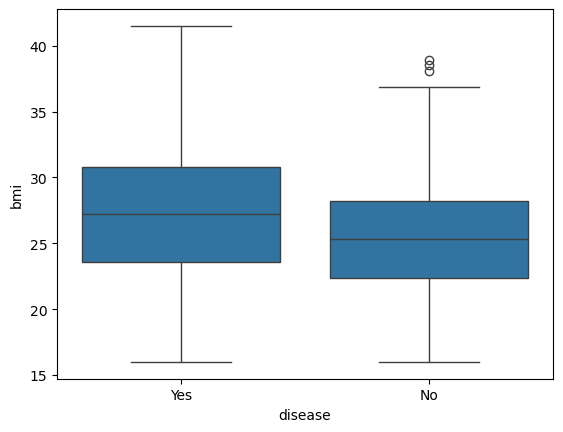

In [61]:
sns.boxplot(data=df, x='disease', y='bmi')
plt.show()

In [62]:
disease_hrt= df.groupby('disease')['heart_rate'].mean()
disease_hrt

disease
No     76.398798
Yes    75.538922
Name: heart_rate, dtype: float64

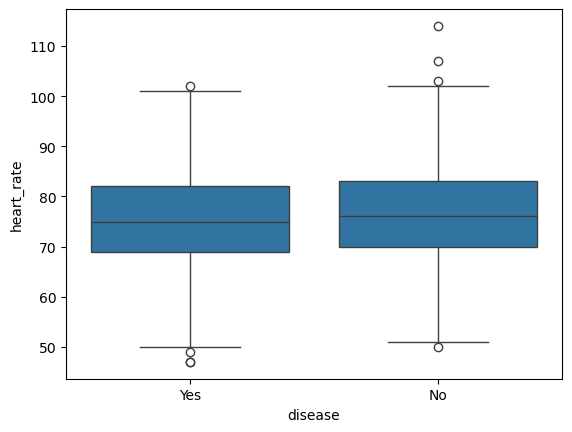

In [63]:
sns.boxplot(data=df, x='disease', y='heart_rate')
plt.show()

In [64]:
g= df['disease'].unique()
groups= [df.groupby('disease')['heart_rate'].get_group(gi)  for gi in g]
f,p = stats.f_oneway(*groups)
print(f'f-value is {f}')
print(f'p-value is {p}')

f-value is 1.8865253335259464
p-value is 0.16990280747594558


In [65]:
corr= df.select_dtypes('number').corr()
corr

,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
age,1.000000,0.016832,0.018901,0.019391,-0.001467,0.014826,0.028607
glucose_mg_dl,0.016832,1.000000,-0.016693,-0.000195,0.024895,0.010417,-0.059644
cholesterol_mg_dl,0.018901,-0.016693,1.000000,0.000834,0.032598,-0.033970,-0.010547
systolic_bp,0.019391,-0.000195,0.000834,1.000000,-0.098728,-0.003552,-0.015120
diastolic_bp,-0.001467,0.024895,0.032598,-0.098728,1.000000,0.013342,0.011264
bmi,0.014826,0.010417,-0.033970,-0.003552,0.013342,1.000000,0.000337
heart_rate,0.028607,-0.059644,-0.010547,-0.015120,0.011264,0.000337,1.000000


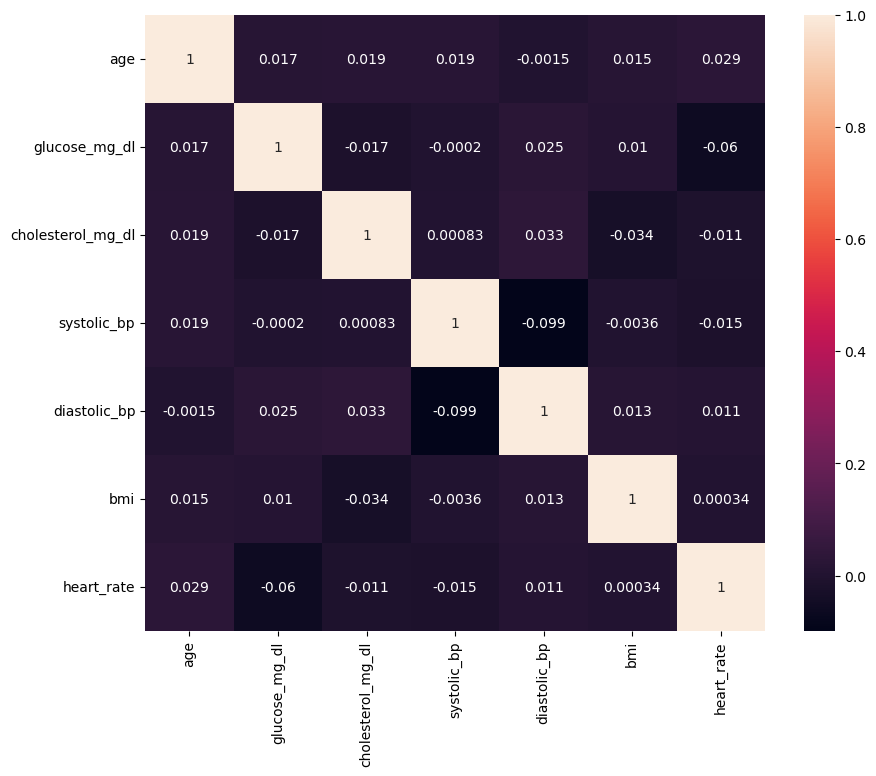

In [66]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

In [67]:
df.select_dtypes('object').columns

Index(['gender', 'smoking', 'alcohol_consumption', 'physical_activity',
       'family_history', 'disease'],
      dtype='object')

In [68]:
ct_gen= pd.crosstab(df["gender"], df['disease'], normalize='index')*100
ct_gen

disease,No,Yes
gender,,
Female,51.587302,48.412698
Male,48.185484,51.814516


<Axes: xlabel='gender'>

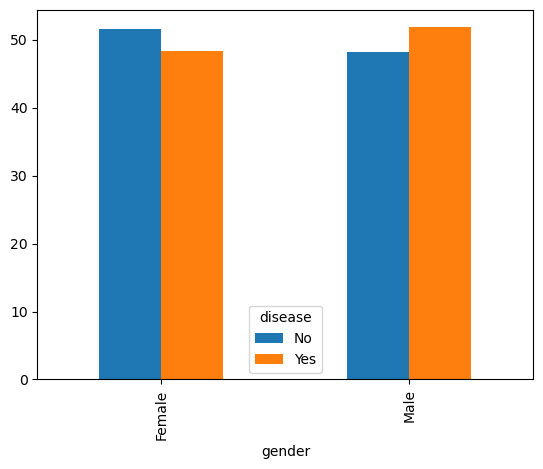

In [69]:
ct_gen.plot(kind='bar')

In [70]:
ct_smk= pd.crosstab(df["smoking"], df['disease'], normalize='index')*100
ct_smk

disease,No,Yes
smoking,,
No,63.983903,36.016097
Yes,35.984095,64.015905


<Axes: xlabel='smoking'>

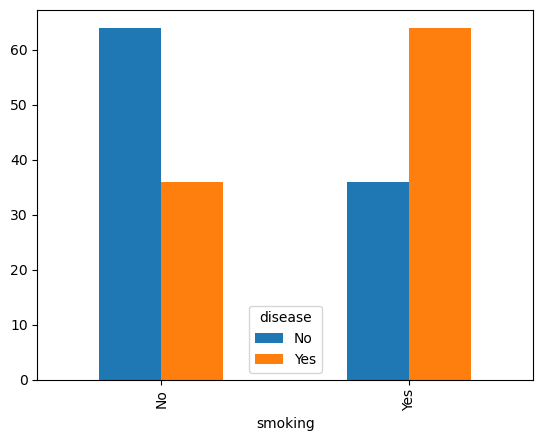

In [71]:
ct_smk.plot(kind='bar')

In [72]:
ct_alc= pd.crosstab(df['disease'], df['alcohol_consumption'], normalize='index')*100
ct_alc

alcohol_consumption,No,Yes
disease,,
No,56.913828,43.086172
Yes,42.914172,57.085828


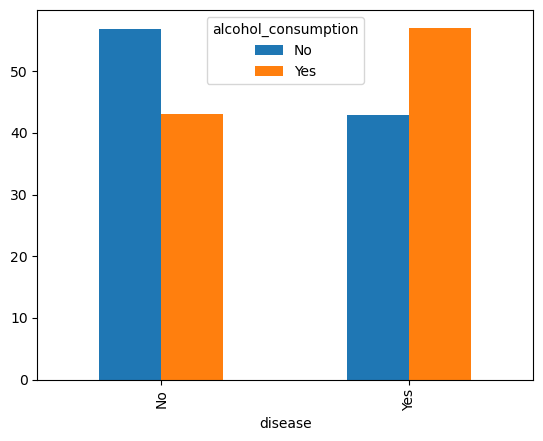

In [73]:
ct_alc.plot(kind='bar');

In [74]:
ct_phy= pd.crosstab(df['disease'], df['physical_activity'], normalize='index')*100
ct_phy

physical_activity,High,Low,Medium
disease,,,
No,46.492986,15.631263,37.875752
Yes,22.355289,46.706587,30.938124


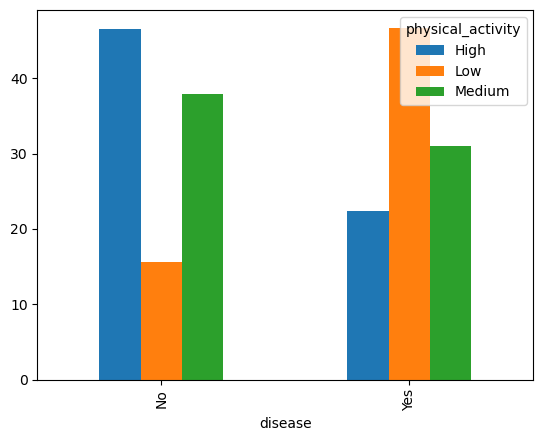

In [75]:
ct_phy.plot(kind='bar');

In [76]:
ct_fam= pd.crosstab(df['disease'], df['family_history'], normalize="index")*100
ct_fam

family_history,No,Yes
disease,,
No,64.529058,35.470942
Yes,36.327345,63.672655


<Axes: xlabel='disease'>

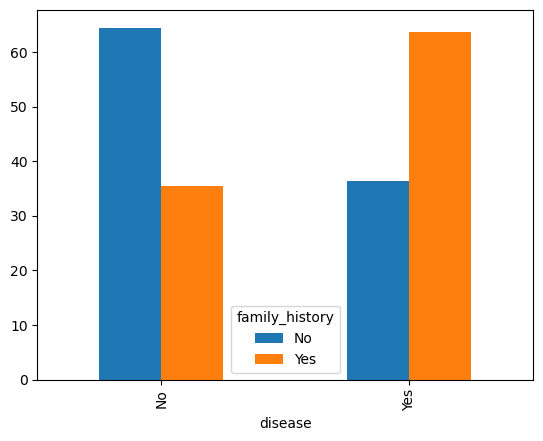

In [77]:
ct_fam.plot(kind='bar')

In [78]:
df.select_dtypes('object').nunique()

gender                 2
smoking                2
alcohol_consumption    2
physical_activity      3
family_history         2
disease                2
dtype: int64

In [79]:
df['physical_activity'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [80]:
cols= ['gender', 'smoking', 'alcohol_consumption', 'family_history', 'disease']

In [81]:
order= [['Low', 'Medium', 'High']]

label= LabelEncoder()
ordinal= OrdinalEncoder(categories= order)


for col in cols:
    df[col]= label.fit_transform(df[col])

df['physical_activity']= ordinal.fit_transform(df[['physical_activity']])

In [82]:
len(df.columns)

13

In [83]:
df.columns

Index(['age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
       'diastolic_bp', 'bmi', 'heart_rate', 'smoking', 'alcohol_consumption',
       'physical_activity', 'family_history', 'disease'],
      dtype='object')

In [84]:
x= df.drop('disease', axis=1)
y= df['disease']

In [85]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state= 1)

In [86]:
linear_models = {
    'Logistic Regression': LogisticRegression( max_iter=1000, random_state=42),
    
}

non_linear_models= {
    'Random Forest':       RandomForestClassifier( n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='aucpr', verbosity=0),
    'LightGBM':            LGBMClassifier( random_state=42, verbose=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

In [87]:
columns= []
preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(),                         columns),
],
    remainder='passthrough'
)

In [88]:
results   = []
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [89]:
for model_name, model in linear_models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),                        
        ('selector',     SelectKBest(                           
                            mutual_info_classif, k=20)),         
        ('model',        model)                                 
    ])

    cv_scores = cross_val_score(
        pipeline, x_train, y_train,
        cv=cv,
        scoring='roc_auc'
    )

    pipeline.fit(x_train, y_train)
    y_pred      = pipeline.predict(x_test)
    y_pred_prob = pipeline.predict_proba(x_test)[:, 1]

    results.append({
        'Model':      model_name,
        'ROC-AUC':    round(roc_auc_score(y_test, y_pred_prob), 4),
        'F1 Score':   round(f1_score(y_test, y_pred), 4),
        'MCC':        round(matthews_corrcoef(y_test, y_pred), 4),
        'CV ROC-AUC': round(cv_scores.mean(), 4),
        'CV Std':     round(cv_scores.std(), 4)
    })
    print(f"\n{'─' * 70}")
    print(f"  {model_name}")
    print(f"{'─' * 70}")
    print(classification_report(y_test, y_pred, target_names=['Not Worthy', 'Worthy']))


C:\Users\baafi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
C:\Users\baafi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
C:\Users\baafi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
C:\Users\baafi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(
C:\Users\baafi\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=12. All the features will be returned.
  warnings.warn(



──────────────────────────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Worthy       0.84      0.85      0.85        94
      Worthy       0.87      0.86      0.86       106

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.86      0.85      0.86       200



In [90]:
for model_name, model in non_linear_models.items():

    pipeline = Pipeline([                              
        ('model',        model)                                 
    ])

    cv_scores = cross_val_score(
        pipeline, x_train, y_train,
        cv=cv,
        scoring='roc_auc'
    )

    pipeline.fit(x_train, y_train)
    y_pred      = pipeline.predict(x_test)
    y_pred_prob = pipeline.predict_proba(x_test)[:, 1]

    results.append({
        'Model':      model_name,
        'ROC-AUC':    round(roc_auc_score(y_test, y_pred_prob), 4),
        'F1 Score':   round(f1_score(y_test, y_pred), 4),
        'MCC':        round(matthews_corrcoef(y_test, y_pred), 4),
        'CV ROC-AUC': round(cv_scores.mean(), 4),
        'CV Std':     round(cv_scores.std(), 4)
    })
    print(f"\n{'─' * 70}")
    print(f"  {model_name}")
    print(f"{'─' * 70}")
    print(classification_report(y_test, y_pred, target_names=['Not Worthy', 'Worthy']))


──────────────────────────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Worthy       0.94      0.90      0.92        94
      Worthy       0.92      0.95      0.94       106

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200


──────────────────────────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Not Worthy       0.98      0.93      0.95        94
      Worthy       0.94      0.98      0.96       106

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200


─────────────────────────────────

In [91]:
print("\n" + "=" * 70)
print("SUMMARY — RANKED BY ROC-AUC")
print("=" * 70)
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df)
print(f"\n✅ Best Model: {results_df.iloc[0]['Model']}")



SUMMARY — RANKED BY ROC-AUC
                 Model  ROC-AUC  F1 Score     MCC  CV ROC-AUC  CV Std
2              XGBoost   0.9909    0.9585  0.9106      0.9905  0.0054
3             LightGBM   0.9895    0.9444  0.8800      0.9836  0.0084
1        Random Forest   0.9818    0.9352  0.8599      0.9770  0.0049
0  Logistic Regression   0.9412    0.8626  0.7092      0.9139  0.0106
4                  KNN   0.6913    0.6061  0.2259      0.7422  0.0372

✅ Best Model: XGBoost


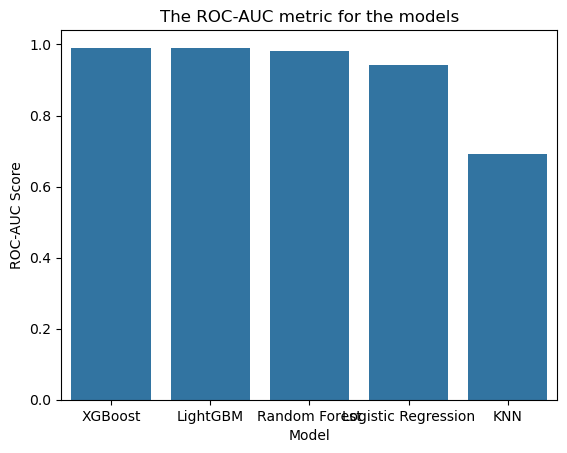

In [92]:
sns.barplot(data= results_df, x= 'Model', y= 'ROC-AUC')
plt.ylabel('ROC-AUC Score')
plt.title('The ROC-AUC metric for the models')
plt.savefig('ROC-AUC score.png')
plt.show()

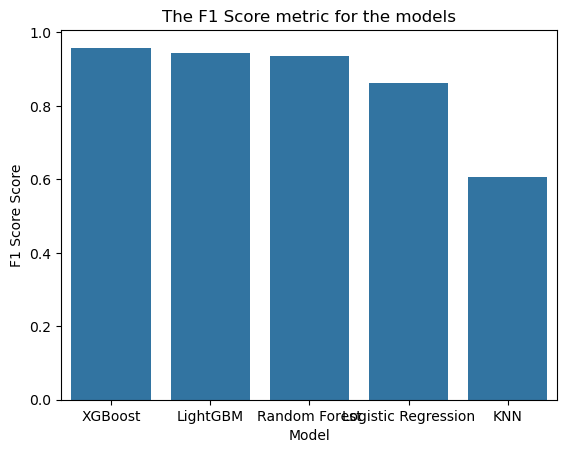

In [93]:
sns.barplot(data= results_df, x= 'Model', y= 'F1 Score')
plt.ylabel('F1 Score Score')
plt.title('The F1 Score metric for the models')
plt.savefig('F1 score.png')
plt.show()

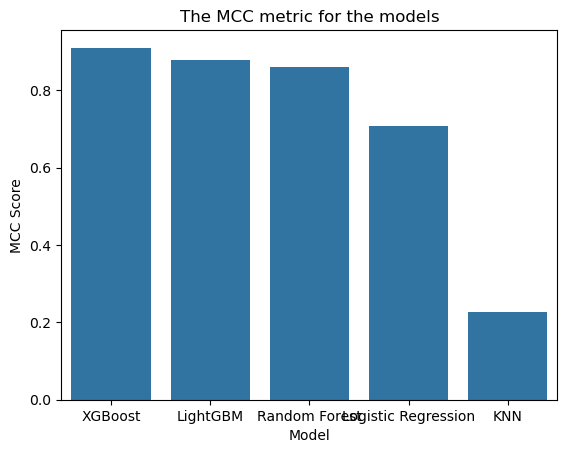

In [94]:
sns.barplot(data= results_df, x= 'Model', y= 'MCC')
plt.ylabel('MCC Score')
plt.title('The MCC metric for the models')
plt.savefig('MCC score.png')
plt.show()

In [95]:
best_pipeline = Pipeline([
    ('model', XGBClassifier(
        scale_pos_weight=3,
        random_state=42,
        eval_metric='aucpr',
        verbosity=0
    ))
])

best_pipeline.fit(x_train, y_train)

# Confirming the quality of the model 
y_pred      = best_pipeline.predict(x_test)
y_pred_prob = best_pipeline.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Worthy', 'Worthy']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

  Not Worthy       0.99      0.90      0.94        94
      Worthy       0.92      0.99      0.95       106

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

ROC-AUC: 0.9896
MCC:     0.9021


In [96]:
# Saving the model
with open('best_heart_disease_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f, protocol=4)